# Deep Learning: Deployment using Streamlit

---

## Lesson Objectives:
- Deploy a deep learning model locally
- Deploy a deep learning model to the web

# Streamlit

**Streamlit** is an open-source Python framework used for building interactive web applications for data science and machine learning. It allows users to create custom web applications with Python code, enabling data scientists to create user interfaces for their models, visualizations, and data analyses without the need for extensive web development knowledge.

With Streamlit, users can create **web applications** by writing Python scripts that define the layout, content, and behavior of the application. Streamlit provides a **simple and intuitive API** that allows developers to easily create custom widgets, data visualizations, and other user interface components.

Streamlit is designed to be highly modular, allowing users to easily integrate with other Python libraries and tools commonly used in data science and machine learning. Additionally, Streamlit's web server is optimized for fast and efficient updates, allowing users to see changes in real-time as they make updates to their code.

**Requirements**:
- Signup/sign-in to Streamlit account
- Signup/sign-in to Github account
- Create a new environment on Anaconda

**Streamlit Installation on Anaconda**
- Open a new terminal on the newly created environment in Anaconda
- Issue the command `pip install streamlit` to install Streamlit
- To test the installation, issue the command `streamlit hello`. You should have installed Streamlit properly on your environment if you see the page with `Welcome to Streamlit!`.
- For reference, browse to https://docs.streamlit.io/library/get-started for installation procedures on any OS.



# Local Deployment

For this tutorial, I assume that you have created your virtual environment in Python. There are two files necessary to deploy the sample app in Streamlit.

1. **Deep learning model** - in this sample I use the model `plant_classifier.hdf5`. This is to assume that you have develop, trained and tested your deep learning model. You need to save your model, which will be loaded in your Streamlit app later.
- Created a directory of the App
- Placed the model inside the directory

2. **Python Script** - in this sample app, I created a file `app.py` and placed it in the same directory. The content of the `app.py` is shown below.








In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


DATASET: https://www.kaggle.com/datasets/hmohamedhussain/leaves-image-dataset

# Since I dont have this model yet, I will use pretrained models to have a ready model for this activity and that will be used to demonstrate the model deployment in Streamlit

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3

In [3]:
IMG_SIZE = (299, 299)
BATCH_SIZE = 8

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/leafs/train/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/leafs/valid/valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/leafs/test/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names) # classes

print(class_names)

Found 4274 files belonging to 12 classes.
Found 110 files belonging to 12 classes.
Found 110 files belonging to 12 classes.
['Alstonia Scholaris', 'Arjun', 'Bael', 'Basil', 'Chinar', 'Gauva', 'Jamun', 'Jatropha', 'Lemon', 'Mango', 'Pomegranate', 'Pongamia Pinnata']


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

In [6]:
base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(299, 299, 3)
)

base_model.trainable = False

In [7]:
x = data_augmentation(base_model.input)
x = tf.keras.applications.inception_v3.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_model.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
534/535 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6170 - loss: 1.3443

535/535 ━━━━━━━━━━━━━━━━━━━━ 1032s 127ms/step - accuracy: 0.7342 - loss: 0.9363 - val_accuracy: 0.8818 - val_loss: 0.3412
Epoch 2/20
534/535 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8276 - loss: 0.5594

535/535 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.8404 - loss: 0.5395 - val_accuracy: 0.9273 - val_loss: 0.2105
Epoch 3/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.8737 - loss: 0.4324 - val_accuracy: 0.9182 - val_loss: 0.1996
Epoch 4/20
534/535 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8924 - loss: 0.3780

535/535 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.8886 - loss: 0.3919 - val_accuracy: 0.9636 - val_loss: 0.1850
Epoch 5/20
534/535 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9020 - loss: 0.3397

535/535 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.9031 - loss: 0.3288 - val_accuracy: 0.9727 - val_loss: 0.1846
Epoch 6/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.9055 - loss: 0.3325 - val_accuracy: 0.9455 - val_loss: 0.1584
Epoch 7/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.9130 - loss: 0.2941 - val_accuracy: 0.9636 - val_loss: 0.1740
Epoch 8/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.9085 - loss: 0.3192 - val_accuracy: 0.9545 - val_loss: 0.0967
Epoch 9/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - accuracy: 0.9207 - loss: 0.2671 - val_accuracy: 0.9364 - val_loss: 0.1989
Epoch 10/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.9268 - loss: 0.2452 - val_accuracy: 0.9364 - val_loss: 0.2085
Epoch 11/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.9275 - loss: 0.2310 - val_accuracy: 0.9273 - val_loss: 0.1948
Epoch 12/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.9317 - loss: 0.2297 - val_accu

In [11]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

14/14 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.9000 - loss: 1.2765
Test Accuracy: 0.8999999761581421


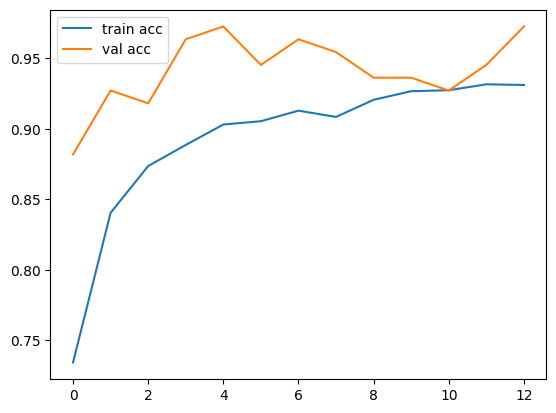

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [13]:
model.save("leaf_classifier_inceptionv3.h5")

# IMPORTING MODEL INTO STREAMLIT

In [5]:
model_path = r'C:\Users\Win10\Downloads\hoa9_2\planters.h5'

In [6]:
import streamlit as st
import tensorflow as tf

@st.cache(allow_output_mutation=True)
def load_model():
  model=tf.keras.models.load_model(model_path) # plant model
  return model
model=load_model()
st.write("""
# Plant Leaf Detection System"""
)
file=st.file_uploader("Choose plant photo from computer",type=["jpg","png"])

import cv2
from PIL import Image,ImageOps
import numpy as np
def import_and_predict(image_data,model):
    size=(64,64)
    image=ImageOps.fit(image_data,size,Image.ANTIALIAS)
    img=np.asarray(image)
    img_reshape=img[np.newaxis,...]
    prediction=model.predict(img_reshape)
    return prediction
if file is None:
    st.text("Please upload an image file")
else:
    image=Image.open(file)
    st.image(image,use_column_width=True)
    prediction=import_and_predict(image,model) # change class names based on the new dataset
    class_names=['Alpinia Galanga (Rasna)','Amaranthus Viridis (Arive-Dantu)',
                 'Artocarpus Heterophyllus (Jackfruit)',
                 'Azadirachta Indica (Neem)','Basella Alba (Basale)',
                 'Brassica Juncea (Indian Mustard)','Carissa Carandas (Karanda)',
                 'Citrus Limon (Lemon)','Ficus Auriculata (Roxburgh fig)',
                 'Ficus Religiosa (Peepal Tree)','Hibiscus Rosa-sinensis',
                 'Jasminum (Jasmine)','Mangifera Indica (Mango)',
                 'Mentha (Mint)','Moringa Oleifera (Drumstick)',
                 'Muntingia Calabura (Jamaica Cherry-Gasagase)',
                 'Murraya Koenigii (Curry)', 'Nerium Oleander (Oleander)',
                 'Nyctanthes Arbor-tristis (Parijata)','Ocimum Tenuiflorum (Tulsi)',
                 'Piper Betle (Betel)','Plectranthus Amboinicus (Mexican Mint)',
                 'Pongamia Pinnata (Indian Beech)','Psidium Guajava (Guava)',
                 'Punica Granatum (Pomegranate)','Santalum Album (Sandalwood)',
                 'Syzygium Cumini (Jamun)','Syzygium Jambos (Rose Apple)',
                 'Tabernaemontana Divaricata (Crape Jasmine)',
                 'Trigonella Foenum-graecum (Fenugreek)']
    string="OUTPUT : "+class_names[np.argmax(prediction)]
    st.success(string)

2026-04-09 17:11:15.638 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 17:11:15.639 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 17:11:15.639 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 17:11:15.640 
`st.cache` is deprecated and will be removed soon. Please use one of Streamlit's new
caching commands, `st.cache_data` or `st.cache_resource`. More information
[in our docs](https://docs.streamlit.io/develop/concepts/architecture/caching).

**Note**: The behavior of `st.cache` was updated in Streamlit 1.36 to the new caching
logic used by `st.cache_data` and `st.cache_resource`. This might lead to some problems
or unexpected behavior in certain edge cases.

2026-04-09 17:11:15.643 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


ValueError: Unknown layer: 'TrueDivide'. Please ensure you are using a `keras.utils.custom_object_scope` and that this object is included in the scope. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.

This code uses the **Streamlit** library to create a web application for a **plant leaf detection system**. The user can upload an image of a plant leaf, and the system will predict the plant species.

How the code works:
```
@st.cache(allow_output_mutation=True)
def load_model():
  model=tf.keras.models.load_model('plant_classifier.hdf5')
  return model
```

1. The `load_model()` function uses **TensorFlow** to load a pre-trained neural network model from a saved file. The `@st.cache` decorator is used to cache the function's output, so it is only loaded once and stored in memory for faster access.

```
def import_and_predict(image_data,model):
    size=(64,64)
    image=ImageOps.fit(image_data,size,Image.ANTIALIAS)
    img=np.asarray(image)
    img_reshape=img[np.newaxis,...]
    prediction=model.predict(img_reshape)
    return prediction
```

2. The `import_and_predict()` function takes the uploaded image data and the pre-trained model as input, preprocesses the image by resizing it to (64,64) pixels, and then makes a prediction using the pre-trained model.

```
st.write("""
# Plant Leaf Detection System"""
)
```

3. The **Streamlit library** is used to create the web application's user interface. The `st.write()` function displays the application's title.

```
file=st.file_uploader("Choose plant photo from computer",type=["jpg","png"])
```

4. The `st.file_uploader()` function creates a file uploader widget for the user to upload an image file.

```
st.image(image,use_column_width=True)
```

5. The `st.image()` function displays the uploaded image.

```
st.success(string)
```
6. The `st.success()` function displays the predicted plant species as output.

```
class_names=['Alpinia Galanga (Rasna)','Amaranthus Viridis (Arive-Dantu)','Artocarpus Heterophyllus (Jackfruit)',
    'Azadirachta Indica (Neem)','Basella Alba (Basale)','Brassica Juncea (Indian Mustard)','Carissa Carandas (Karanda)','Citrus Limon (Lemon)','Ficus Auriculata (Roxburgh fig)','Ficus Religiosa (Peepal Tree)', 'Hibiscus Rosa-sinensis','Jasminum (Jasmine)','Mangifera Indica (Mango)', 'Mentha (Mint)','Moringa Oleifera (Drumstick)', 'Muntingia Calabura (Jamaica Cherry-Gasagase)','Murraya Koenigii (Curry)', 'Nerium Oleander (Oleander)','Nyctanthes Arbor-tristis (Parijata)','Ocimum Tenuiflorum (Tulsi)','Piper Betle (Betel)','Plectranthus Amboinicus (Mexican Mint)','Pongamia Pinnata (Indian Beech)','Psidium Guajava (Guava)','Punica Granatum (Pomegranate)', 'Santalum Album (Sandalwood)','Syzygium Cumini (Jamun)',
    'Syzygium Jambos (Rose Apple)', 'Tabernaemontana Divaricata (Crape Jasmine)', 'Trigonella Foenum-graecum (Fenugreek)']
```

7. The `class_names` list contains the names of the plant species that the model can predict.

```
string="OUTPUT : "+class_names[np.argmax(prediction)]
```

8. The `np.argmax()` function is used to find the index of the predicted class with the highest probability, which is then used to get the corresponding plant species name from the `class_names` list.

> Note: This code creates a simple and user-friendly web application for predicting plant species from leaf images using pre-trained neural network models.


In order to run the Streamlit app, notice that we need to install and import the following:
```
import streamlit as st
import tensorflow as tf
import cv2
from PIL import Image,ImageOps
import numpy as np
```




# Web Deployment

**Requirements**:

- Github account
- Streamlit account

**Instructions**:

1. Sign in to Streamlit using either Google account or Github account

<img src= 'https://i.ibb.co/ssMhKZX/Screenshot-2023-05-09-at-5-49-03-PM.png'  width=350/>


2. In the New App button, you can select to create a NEW APP, load existing repo or load from a sample app template.

<img src='https://i.ibb.co/pfr5rHZ/Screenshot-2023-05-09-at-5-53-38-PM.png' width=350 />

3. In this tutorial, click the NEW APP. Supply the information as needed.

<img src='https://i.ibb.co/x7p6N18/Screenshot-2023-05-09-at-5-56-52-PM.png' width=350 />


- Supply the correct path for your Github repository. In my case, I supplied it with the path to the file: `https://github.com/jvtaylar-cpe/streamlit-example`

- Provide the Branch as master
- Lastly, provide the name of your file. In this image, you will see `streamlit_app.py.` In my case, I supplied it with `app.py` which is located in my repository.

You are now ready to deploy the APP.

> **Troubleshooting**: If problems occur, you can troubleshoot the errors in the `Manage App`, which is located on the lower right part of the deployed web app.  

<img src='https://i.ibb.co/tC2XvGm/Screenshot-2023-05-09-at-6-05-39-PM.png' width=600 />



If your APP does not have a problem, it may successfully load and perform the function accordingly. Below is a sample of the successful deployment and testing.

<img src = 'https://i.ibb.co/6PRb4bD/Screenshot-2023-05-09-at-6-11-43-PM.png' width=600 />



> **Important Notes**:
1. Streamlit
2. Google or Github account
3. Environment of your Deep Learning Model


**References**:
1. Learn more on: https://docs.streamlit.io/library/get-started
2. Other deployment: **FLASK** - https://flask.palletsprojects.com/en/2.3.x/
